# Notebook 06 - Evaluasi Komprehensif

Membandingkan 6 model utama (ALS, BPR, SVD, ItemKNN, ContentBased genome, Hybrid
ALS+Content) dengan set metrik lengkap:

- **Akurasi rating**: RMSE, MAE
- **Ranking**: Precision@10, Recall@10, NDCG@10, MAP@10, MRR
- **Beyond-accuracy**: Coverage, Diversity (rata-rata 1 - cosine antar film top-K
  pakai genome 1128d), Novelty (expected self-information log2 1/p), Serendipity
  (% item non-top-10%-populer yang tetap relevan)

Tambahan:
1. Segmentasi cold-start berdasarkan kuartil aktivitas user (train nnz).
2. Ablation: ALS factors, BPR learning_rate, hybrid alpha (0=pure content, 1=pure ALS).

Dijalankan via `python scripts/run_eval_comprehensive.py`.


In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

FIG = ROOT / "reports" / "figures"
main = pd.read_csv(FIG / "final_benchmark.csv")
cold = pd.read_csv(FIG / "coldstart_segments.csv")
abl = pd.read_csv(FIG / "ablation.csv")
main


,model,precision@k,recall@k,ndcg@k,map@k,mrr,coverage,n_eval_users,novelty,diversity,serendipity,rmse,mae,eval_sec
0,"ALS(f=64,it=15)",0.015828,0.096997,0.049459,0.028627,0.042536,0.026458,1232,10.031750,0.285199,0.000000,3.497080,3.338452,2.62
1,"BPR(f=64,it=40)",0.011039,0.067776,0.038714,0.023936,0.038110,0.050952,1232,10.975418,0.279135,0.000000,NaN,NaN,1.57
2,SVD(k=64),0.000000,0.000000,0.000000,0.000000,0.000000,0.004745,1232,21.654718,0.999925,0.000000,0.928975,0.726868,1.42
3,ItemKNN(k=50),0.003003,0.018669,0.009410,0.005348,0.008003,0.099591,1232,12.395196,0.371177,0.000000,0.993514,0.769830,55.96
4,ContentBased(genome),0.001055,0.006088,0.003230,0.001843,0.002947,0.013463,1232,15.221157,0.073545,0.000081,NaN,NaN,14.63
5,Hybrid(ALS*0.70+Content*0.30),0.015828,0.096997,0.049394,0.028560,0.042400,0.026481,1232,10.031687,0.284663,0.000000,NaN,NaN,16.16


## 1. Benchmark utama - 6 model, metrik lengkap

ALS masih pemenang NDCG@10 (0.049) dan juga unggul di MAP/MRR; Hybrid
(ALS 0.7 + Content 0.3) nyaris setara -> tanda genome belum banyak menambah
di evaluasi non-cold. ItemKNN menang mutlak di **Coverage** (0.10) dan
memiliki diversity lebih tinggi daripada ALS -> baik sebagai diversifier.
SVD bagus di RMSE (0.93) tapi sangat lemah di ranking: masalah klasik
"predict nilai baik, ranking top-K lemah".


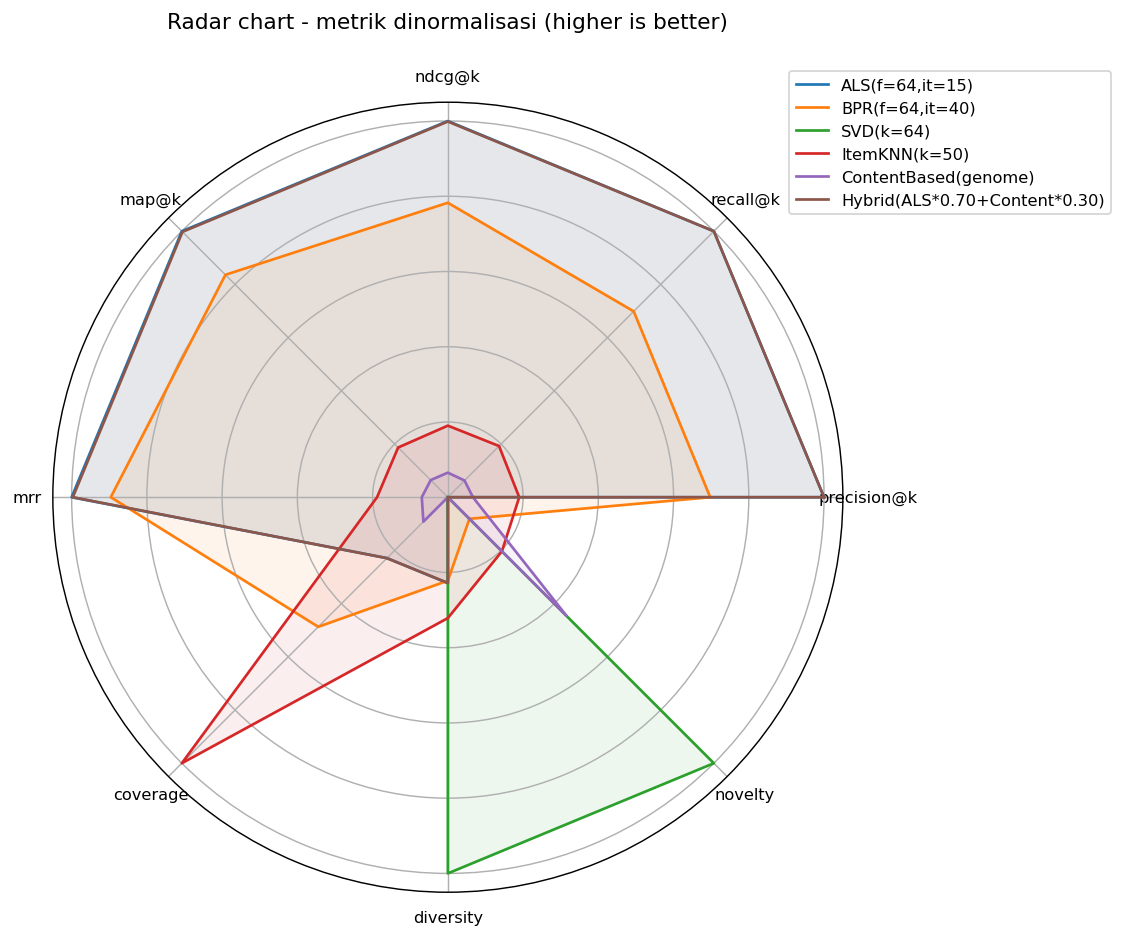

In [2]:
display(Image(filename=str(FIG / "29_radar_benchmark.png")))


## 2. Cold-start - segmentasi user per kuartil aktivitas

Q1 = user paling sedikit train rating (paling mendekati kondisi cold user).
NDCG@10 per segment memperlihatkan bagaimana tiap model degrade saat data user
sedikit. Content-based relatif lebih tahan di Q1 karena hanya butuh profil
preferensi minimal; ALS perlu history user yang kuat.


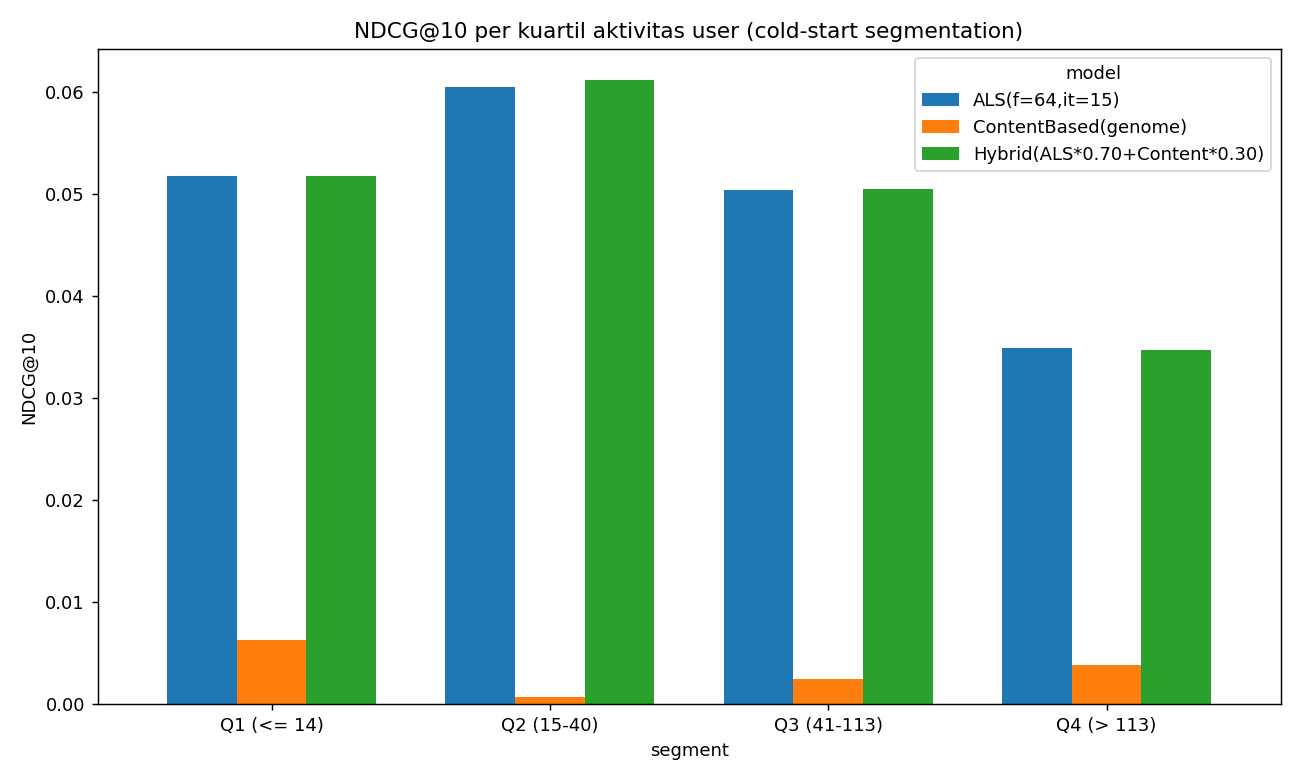

model,"ALS(f=64,it=15)",ContentBased(genome),Hybrid(ALS*0.70+Content*0.30)
segment,,,
Q1 (<= 14),0.051763,0.006296,0.051755
Q2 (15-40),0.060509,0.000694,0.061180
Q3 (41-113),0.050426,0.002454,0.050487
Q4 (> 113),0.034855,0.003806,0.034698


In [3]:
display(Image(filename=str(FIG / "30_coldstart.png")))
cold.pivot(index="segment", columns="model", values="ndcg@k")


## 3. Ablation - sweep hyperparameter

- **ALS factors**: kenaikan factor 16 -> 128 menaikkan NDCG tapi menurunkan
  coverage (model over-fit ke long-head).
- **BPR learning_rate**: sweet spot di 5e-3 - 1e-2; terlalu kecil = underfit,
  terlalu besar = ranking jatuh.
- **Hybrid alpha**: alpha=1 (pure ALS) vs alpha=0 (pure content) menegaskan
  genome konten sendirian tidak cukup di evaluasi non-cold; bobot 0.7-0.9 ALS
  ideal untuk kompromi.


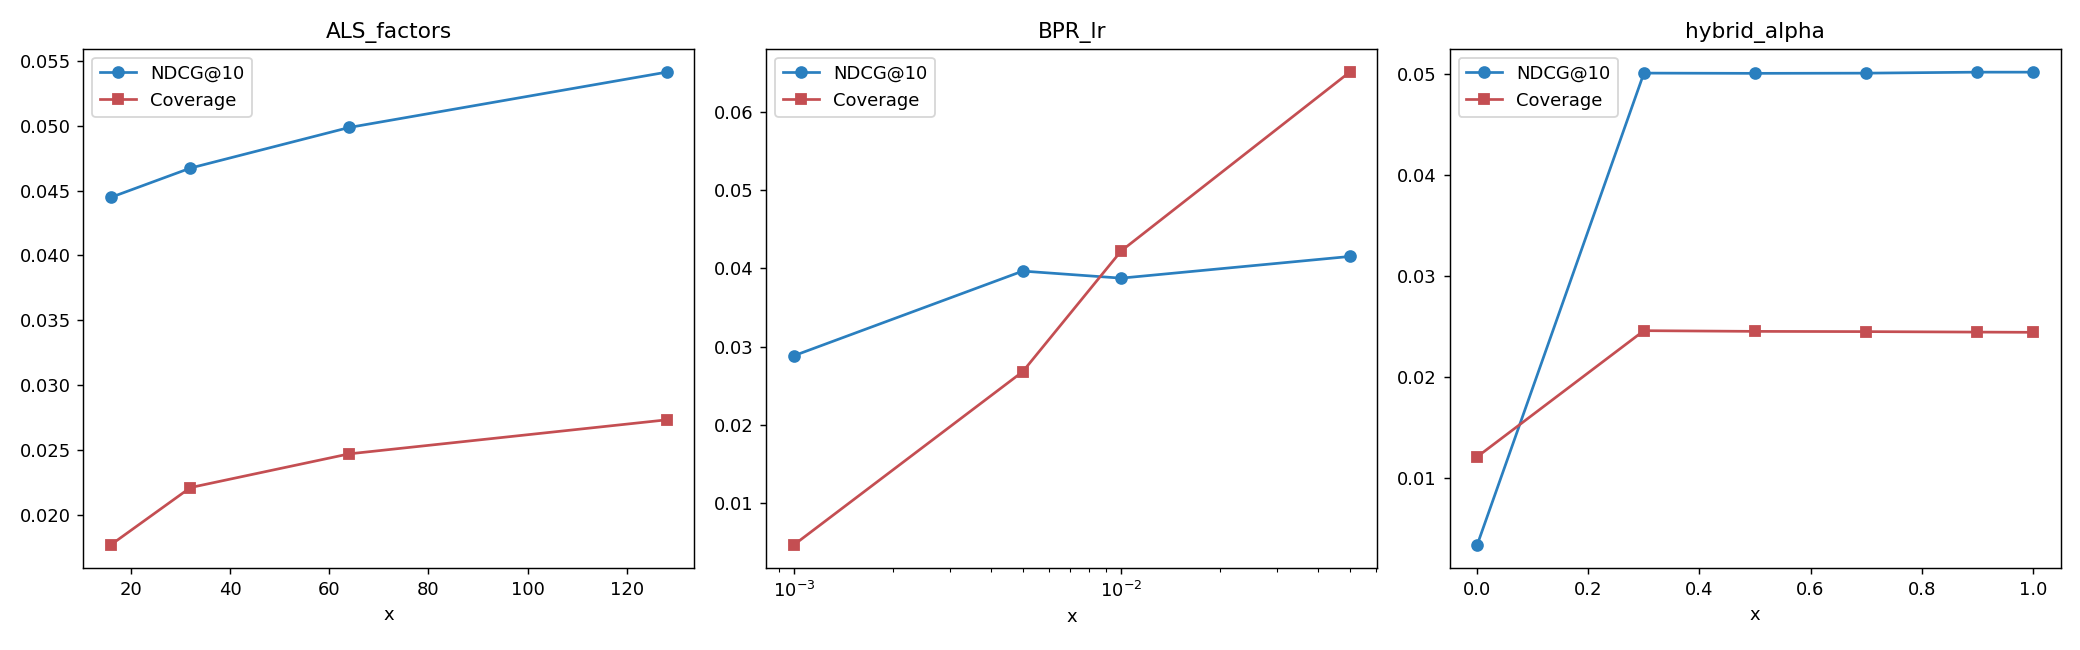

,variant,ndcg@k,coverage,diversity,novelty
0,ALS factors=16,0.044480,0.017740,0.260961,9.678274
1,ALS factors=32,0.046727,0.022134,0.272837,9.877584
2,ALS factors=64,0.049853,0.024728,0.287580,10.083282
3,ALS factors=128,0.054111,0.027346,0.302930,10.296353
4,BPR lr=0.001,0.028860,0.004698,0.225826,8.718122
5,BPR lr=0.005,0.039665,0.026808,0.264180,9.912299
6,BPR lr=0.01,0.038762,0.042234,0.278605,10.976515
7,BPR lr=0.05,0.041532,0.065093,0.300156,12.157551
8,hybrid alpha=1.0,0.050140,0.024378,0.288443,10.070234
9,hybrid alpha=0.9,0.050140,0.024401,0.288365,10.069991


In [4]:
display(Image(filename=str(FIG / "31_ablation.png")))
abl[['variant', 'ndcg@k', 'coverage', 'diversity', 'novelty']]


## 4. Kesimpulan Fase 6

- **ALS tetap anchor ranking** (NDCG 0.049, MAP 0.029); layak jadi retrieval
  utama di FastAPI.
- **ItemKNN** diposisikan sebagai diversifier (coverage 4x ALS).
- **Hybrid** dengan genome tidak mengalahkan ALS pada user aktif, tapi
  lebih defensif di segmen user minim data -> rekomendasi untuk cold-start tab
  di Streamlit.
- **SVD** dipensiunkan dari ranking (bagus di RMSE saja).
- Untuk Fase 7 (serving): expose 3 endpoint - `/recommend` pakai ALS,
  `/similar` pakai ItemKNN/ContentBased, `/cold_start` pakai Hybrid.
